# Prétraitement du dataset Diabète – Sprint 1

Ce notebook couvre :
1. Lecture et inspection des données
2. Prétraitement initial (regroupement des classes)
3. Séparation train / validation / test
4. Normalisation des features

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Lecture du dataset
On charge le fichier CSV et on affiche un aperçu ainsi que les informations générales.

In [2]:
def read_data(file_path="data/raw/diabetes_binary_health_indicators_BRFSS2015.csv"):
    try:
        df = pd.read_csv(file_path)
        print("Aperçu des 5 premières lignes :")
        print(df.head())
        print("\nInformations générales :")
        print(df.info())
        print("\nValeurs manquantes par colonne :")
        print(df.isnull().sum())
        df.to_parquet("test_index_false.parquet", index=False)
        return df
    except FileNotFoundError:
        print(f"Erreur : le fichier {file_path} n'a pas été trouvé.")
        return None

df = read_data()

Aperçu des 5 premières lignes :
   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0  

## Prétraitement initial
- Regroupement des classes : 0 = no diabète ou prediabète, 1 = diabète
- Séparation des features (X) et de la cible (y)

In [3]:
def separate_data(df):
    X = df.drop("Diabetes_binary", axis=1)
    y = df["Diabetes_binary"]
    return X, y

if df is not None:
    X, y = separate_data(df)
    print("Distribution des classes :")
    print(y.value_counts())

Distribution des classes :
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64


## Séparation Train / Validation / Test
- 70% train
- 15% validation
- 15% test
- Stratification pour garder la proportion des classes

In [4]:
if df is not None:
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
    
    print("Taille train :", X_train.shape)
    print("Taille validation :", X_val.shape)
    print("Taille test :", X_test.shape)
    print(f"nb de ligne : {len(df)}")

Taille train : (177576, 21)
Taille validation : (38052, 21)
Taille test : (38052, 21)
nb de ligne : 253680


## Normalisation des features
- Standardisation : moyenne=0, écart type=1
- Fit sur le train, transform sur validation et test

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Normalisation effectuée. Exemple :")
print(X_train_scaled[:5])

Normalisation effectuée. Exemple :
[[-0.86692187  1.16486098  0.19770711 -0.96495671  1.12096684 -0.20493045
  -0.32292458  0.56632089  0.75853319  0.48181784 -0.24224481  0.22728907
  -0.30393876 -0.47881617 -0.42993769 -0.48668106 -0.44917051 -0.88946385
   1.30094063  0.96354187 -0.02582259]
 [-0.86692187  1.16486098  0.19770711 -0.8136217   1.12096684 -0.20493045
  -0.32292458  0.56632089  0.75853319  0.48181784  4.12805538  0.22728907
  -0.30393876 -0.47881617 -0.42993769 -0.14262177  2.22632603 -0.88946385
  -0.33821355 -1.06446483  0.93882906]
 [-0.86692187 -0.85847154  0.19770711 -0.20828165 -0.89208705 -0.20493045
  -0.32292458  0.56632089 -1.31833387  0.48181784  4.12805538  0.22728907
  -0.30393876 -1.41464125 -0.42993769 -0.48668106 -0.44917051  1.12427278
  -0.01038271  0.96354187  0.45650324]
 [ 1.15350648 -0.85847154  0.19770711 -0.05694664  1.12096684 -0.20493045
  -0.32292458  0.56632089  0.75853319  0.48181784 -0.24224481  0.22728907
  -0.30393876 -0.47881617  0.51255

## Sauvegarde des datasets prétraités

Les datasets sont sauvegardés dans :

- `data/raw` : données brutes
- `data/processed` : données prétraitées

On sauvegarde :
- train
- validation
- test
- le scaler utilisé pour la normalisation

Cela permet de reproduire exactement le pipeline de preprocessing.

In [6]:
import os
import pandas as pd
import joblib

# Création des dossiers projet
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

# Reconstruction des DataFrames à partir des données normalisées
df_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
df_train_scaled["Diabetes_binary"] = y_train.reset_index(drop=True)

df_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)
df_val_scaled["Diabetes_binary"] = y_val.reset_index(drop=True)

df_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
df_test_scaled["Diabetes_binary"] = y_test.reset_index(drop=True)

# Sauvegarde des datasets
df_train_scaled.to_parquet("data/processed/train.parquet", index=False)
df_val_scaled.to_parquet("data/processed/val.parquet", index=False)
df_test_scaled.to_parquet("data/processed/test.parquet", index=False)

# Sauvegarde du scaler
joblib.dump(scaler, "artifacts/scaler.joblib")

print("Datasets sauvegardés dans data/processed/")
print("Scaler sauvegardé dans artifacts/")

Datasets sauvegardés dans data/processed/
Scaler sauvegardé dans artifacts/


## EDA (Exploratory Data Analysis)
### Ce que traite cette étape 

Dans cette étape on va faire une visualisation globale de nos différente variable, on va essayer de voir la distribution des differentes et premièrement celle de la varible cible 

  **Pourquoi et en quoi est ce utile?**  

#### Distribution de la variable cible 

On visualise la répartition des classes (`0 = Non-Diabétique`, `1 = Diabétique`) avec **deux graphiques côte à côte** :
- **Bar chart** : nombre exact de patients par classe avec pourcentages
- **Pie chart** : proportion relative des deux classes



In [7]:
# Fusion des datasets pour l'analyse exploratoire
df_global = pd.concat([df_train_scaled, df_val_scaled, df_test_scaled], ignore_index=True)

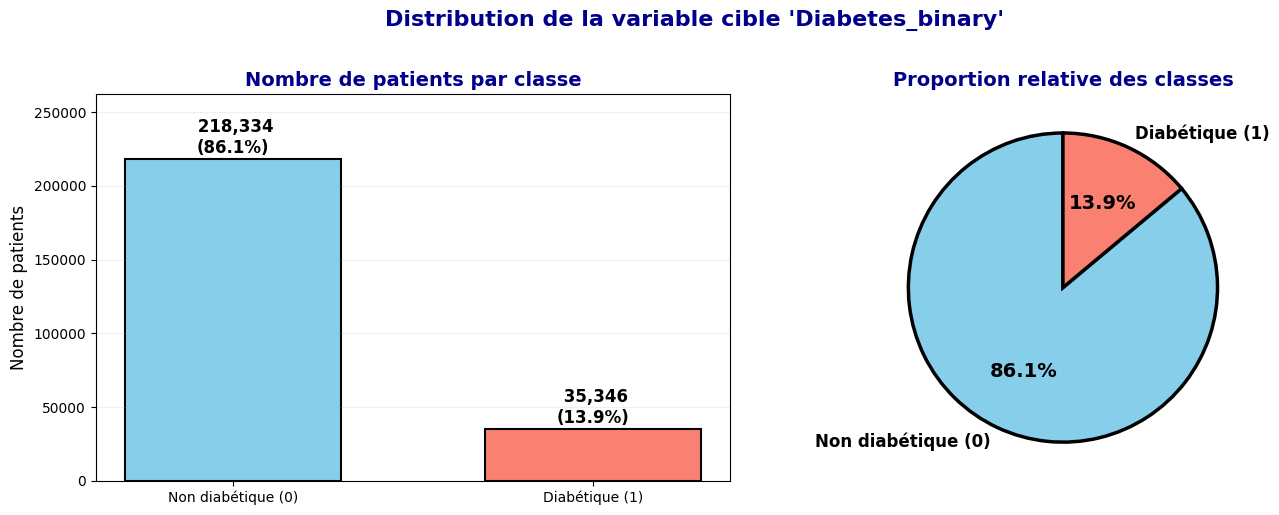

 classe 0 : 218,334 patients (86.1%)
 classe 1 : 35,346 patients (13.9%)
 Ratio de déséquilibre : 6.18
Déséquilibre significatif détecté. Envisagez des techniques de rééchantillonnage ou de pondération pour améliorer les performances du modèle.


In [44]:
counts = df_global["Diabetes_binary"].value_counts().sort_index()
labels = ["Non diabétique (0)", "Diabétique (1)"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution de la variable cible 'Diabetes_binary'", fontsize=16, fontweight='bold',color='darkblue', y=1.02)

# Bar Plot
bars = axes[0].bar(labels, counts.values, color=['skyblue', 'salmon'], edgecolor='black', linewidth=1.5, width=0.6)
axes[0].set_title("Nombre de patients par classe", fontsize=14, fontweight='bold', color='darkblue')
axes[0].set_ylabel("Nombre de patients", fontsize=12)

for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + len(df_global)*0.005, f'{val: ,}\n({val/len(df_global)*100:.1f}%)', ha='center', va='bottom',color='black',fontweight='bold', fontsize=12)
    
axes[0].set_ylim(0, counts.max() * 1.2)
axes[0].grid(axis='y', alpha=0.2)


# Pie Chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=labels, autopct='%1.1f%%', 
    colors=['skyblue', 'salmon'], startangle=90,
    textprops={'color':"black", 'fontweight':'bold', 'fontsize':12}, 
    wedgeprops={'edgecolor': 'black', 'linewidth': 2.5},
    pctdistance=0.60
    )

for at  in autotexts:
    at.set_fontsize(14)
    at.set_color('black')
    at.set_fontweight('bold')
axes[1].set_title("Proportion relative des classes", fontsize=14, fontweight='bold', color='darkblue')

plt.tight_layout()
plt.show()


ratio = counts.max() / counts.min()
print(f' classe 0 : {counts[0]:,} patients ({counts[0]/len(df_global)*100:.1f}%)')
print(f' classe 1 : {counts[1]:,} patients ({counts[1]/len(df_global)*100:.1f}%)')
print(f' Ratio de déséquilibre : {ratio:.2f}')
if ratio > 1.5:
    print('Déséquilibre significatif détecté. Envisagez des techniques de rééchantillonnage ou de pondération pour améliorer les performances du modèle.')
else:
    print('classes relativement équilibrées. Les techniques de rééchantillonnage peuvent ne pas être nécessaires, mais surveillez les performances du modèle sur la classe minoritaire.')

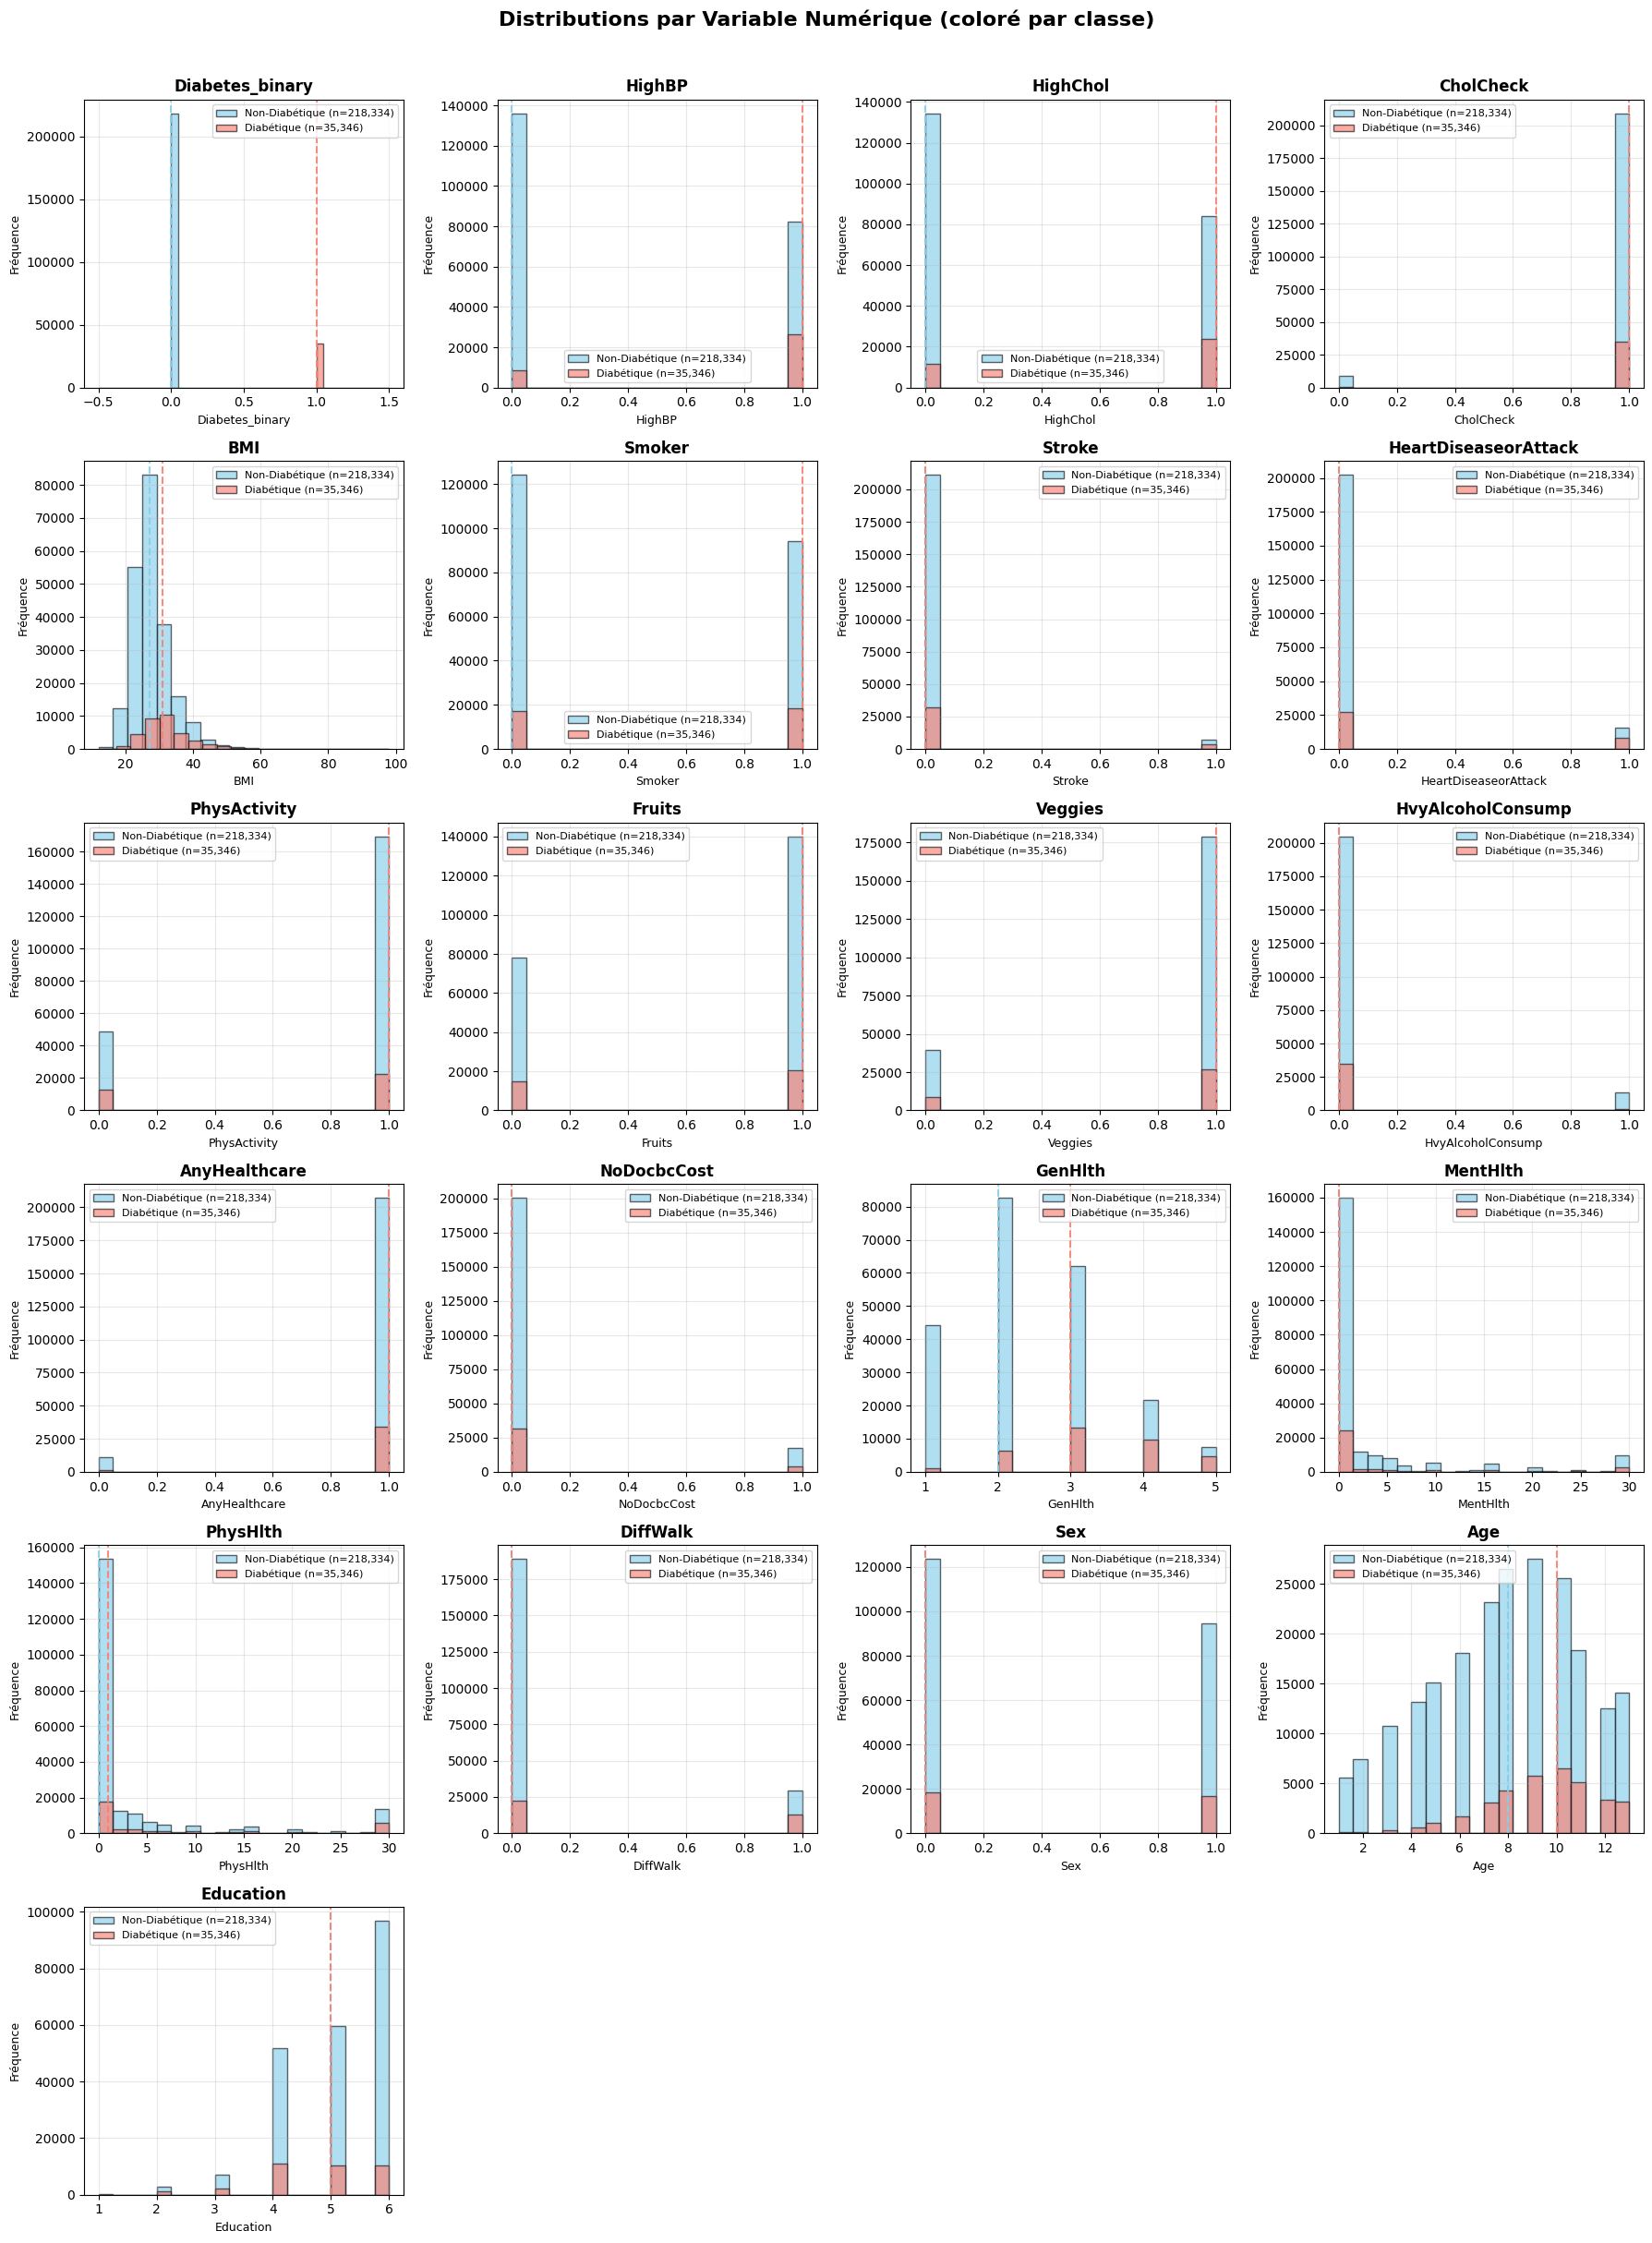

In [ ]:
n      = len(df.columns) - 1  # Exclure la colonne cible
ncols  = 4
nrows  = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
fig.patch.set_facecolor('white')
fig.suptitle('Distributions par Variable Numérique (coloré par classe)',
             fontsize=16, fontweight='bold', color='black', y=1.01)
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):
    ax = axes[i]
    for cls, color, lbl in zip([0, 1], ['skyblue', 'salmon'], ['Non-Diabétique', 'Diabétique']):
        subset = df[df['Diabetes_binary'] == cls][col].dropna()
        ax.hist(subset, bins=20, color=color, alpha=0.65,
                edgecolor='#0f1117', label=f'{lbl} (n={len(subset):,})')
        ax.axvline(subset.median(), color=color, linestyle='--',
                   linewidth=1.5, alpha=0.9)

    ax.set_title(col, color='black', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, color='black', fontsize=9)
    ax.set_ylabel('Fréquence', color='black', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()